In [1]:
%pip install -q ultralytics iterative-stratification

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 84.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23

In [2]:
import os
from pathlib import Path

import yaml
import torch
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO

KAGGLE = os.environ.get("KAGGLE_KERNEL_RUN_TYPE") is not None
if not KAGGLE:
    raise EnvironmentError("This notebook is configured for Kaggle only.")

INPUT_ROOT = Path("/kaggle/input")
WORK_ROOT = Path("/kaggle/working")
TEMP_ROOT = Path("/kaggle/temp")

print("Kaggle mode:", KAGGLE)
print("Input root:", INPUT_ROOT)
print("Working root:", WORK_ROOT)
print("Temp root:", TEMP_ROOT)

if not INPUT_ROOT.exists():
    raise FileNotFoundError("/kaggle/input not found.")
if not WORK_ROOT.exists():
    raise FileNotFoundError("/kaggle/working not found.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Kaggle mode: True
Input root: /kaggle/input
Working root: /kaggle/working
Temp root: /kaggle/temp


In [3]:
DEVICE = 0 if torch.cuda.is_available() else "cpu"
BATCH = 16 if torch.cuda.is_available() else 4
WORKERS = 4 if torch.cuda.is_available() else 2

PROJECT = WORK_ROOT / "runs"
RUN_NAME = "yolo11s_indian_food"

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("CUDA version:", torch.version.cuda)
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM (GB):", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2))

print("DEVICE =", DEVICE)
print("BATCH =", BATCH)
print("WORKERS =", WORKERS)
print("PROJECT =", PROJECT)
print("RUN_NAME =", RUN_NAME)

PyTorch: 2.10.0+cu128
CUDA available: True
CUDA version: 12.8
GPU: Tesla T4
VRAM (GB): 15.64
DEVICE = 0
BATCH = 16
WORKERS = 4
PROJECT = /kaggle/working/runs
RUN_NAME = yolo11s_indian_food


In [4]:
RESUME_CKPT = Path("/kaggle/input/datasets/mrsingh710/training-checkpoint/runs/yolo11s_indian_food/weights/last.pt")
YAML_PATH = Path("/kaggle/input/datasets/mrsingh710/food-dataset/food_dataset/data.yaml")

print("Checkpoint:", RESUME_CKPT)
print("YAML:", YAML_PATH)

if not RESUME_CKPT.exists():
    raise FileNotFoundError(f"Checkpoint not found: {RESUME_CKPT}")
if not YAML_PATH.exists():
    raise FileNotFoundError(f"YAML file not found: {YAML_PATH}")

Checkpoint: /kaggle/input/datasets/mrsingh710/training-checkpoint/runs/yolo11s_indian_food/weights/last.pt
YAML: /kaggle/input/datasets/mrsingh710/food-dataset/food_dataset/data.yaml


In [5]:
with open(YAML_PATH, "r") as f:
    data = yaml.safe_load(f)

data["path"] = str(YAML_PATH.parent)

yaml_dst = Path("/kaggle/working/data.yaml")
with open(yaml_dst, "w") as f:
    yaml.safe_dump(data, f, sort_keys=False)

print("Training YAML:", yaml_dst)
print("Dataset root:", data["path"])
print("Train split:", data.get("train"))
print("Val split:", data.get("val"))
print("Test split:", data.get("test"))

Training YAML: /kaggle/working/data.yaml
Dataset root: /kaggle/input/datasets/mrsingh710/food-dataset/food_dataset
Train split: train/images
Val split: valid/images
Test split: test/images


In [6]:
print("Starting training with checkpoints...")

model = YOLO(str(RESUME_CKPT))

results = model.train(
    resume=True,
    data=str(yaml_dst),
    task="detect",
    epochs=100,
    imgsz=640,
    batch=BATCH,
    patience=20,
    device=DEVICE,
    workers=WORKERS,
    amp=True,
    project=str(PROJECT),
    name=RUN_NAME,
    exist_ok=True,
    save=True,
    save_period=10,
    plots=True,
)

print("Training completed.")
print("Run directory:", results.save_dir)

Starting training with checkpoints...
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/input/datasets/mrsingh710/training-checkpoint/runs/yolo11s_indian_food/weights/last.pt, momentum=0.937, mosaic=1.0, multi_sca

In [7]:
import shutil

RUN_DIR = PROJECT / RUN_NAME
WEIGHTS_DIR = RUN_DIR / "weights"

BEST_MODEL = WEIGHTS_DIR / "best.pt"
LAST_MODEL = WEIGHTS_DIR / "last.pt"

EXPORT_BEST = WORK_ROOT / "yolo11s_indian_food_best.pt"
EXPORT_LAST = WORK_ROOT / "yolo11s_indian_food_last.pt"
EXPORT_RESUME = WORK_ROOT / "last.pt"

print("Run directory:", RUN_DIR)
print("Weights directory:", WEIGHTS_DIR)

if BEST_MODEL.exists():
    shutil.copy2(BEST_MODEL, EXPORT_BEST)
    print("Copied best model:", EXPORT_BEST)
else:
    print("Warning: best.pt not found")

if LAST_MODEL.exists():
    shutil.copy2(LAST_MODEL, EXPORT_LAST)
    shutil.copy2(LAST_MODEL, EXPORT_RESUME)
    print("Copied last model:", EXPORT_LAST)
    print("Updated resume checkpoint:", EXPORT_RESUME)
else:
    print("Warning: last.pt not found")

epoch_checkpoints = sorted(WEIGHTS_DIR.glob("epoch*.pt"))
print(f"Periodic checkpoints found: {len(epoch_checkpoints)}")
for ckpt in epoch_checkpoints[-10:]:
    print(" -", ckpt.name)

Run directory: /kaggle/working/runs/yolo11s_indian_food
Weights directory: /kaggle/working/runs/yolo11s_indian_food/weights
Copied best model: /kaggle/working/yolo11s_indian_food_best.pt
Copied last model: /kaggle/working/yolo11s_indian_food_last.pt
Updated resume checkpoint: /kaggle/working/last.pt
Periodic checkpoints found: 4
 - epoch60.pt
 - epoch70.pt
 - epoch80.pt
 - epoch90.pt


In [8]:
if not EXPORT_BEST.exists():
    raise FileNotFoundError(f"Best model not found for validation: {EXPORT_BEST}")

best_model = YOLO(str(EXPORT_BEST))

val_metrics = best_model.val(
    data=str(yaml_dst),
    device=DEVICE,
    split="val",
)

print("Validation completed.")
print("mAP50-95:", val_metrics.box.map)
print("mAP50:", val_metrics.box.map50)
print("mAP75:", val_metrics.box.map75)

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,440,664 parameters, 0 gradients, 21.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 90.8±50.8 MB/s, size: 55.1 KB)
val: Scanning /kaggle/input/datasets/mrsingh710/food-dataset/food_dataset/valid/labels... 5922 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5922/5922 572.8it/s 10.3s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/mrsingh710/food-dataset/food_dataset/valid is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 371/371 4.2it/s 1:28
                   all       5922       8812      0.847      0.807       0.83      0.692
             aloo_gobi        119        121      0.962      0.967       0.99      0.927
           aloo_masala        111        115      0.936      0.939      0.969       0.91
                 appam         45         50      0

In [9]:
test_metrics = best_model.val(
    data=str(yaml_dst),
    device=DEVICE,
    split="test",
)

print("Test evaluation completed.")
print("mAP50-95:", test_metrics.box.map)
print("mAP50:", test_metrics.box.map50)
print("mAP75:", test_metrics.box.map75)

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.3±0.3 ms, read: 14.7±16.0 MB/s, size: 76.5 KB)
val: Scanning /kaggle/input/datasets/mrsingh710/food-dataset/food_dataset/test/labels... 5919 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5919/5919 180.6it/s 32.8s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/mrsingh710/food-dataset/food_dataset/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 370/370 4.2it/s 1:28
                   all       5919       8875      0.842      0.801       0.82       0.68
             aloo_gobi        119        120       0.98      0.992      0.988      0.908
           aloo_masala        112        113      0.964      0.958      0.973      0.902
                 appam         45         47      0.544      0.489      0.542      0.341
      beetroot_poriyal         45         63    

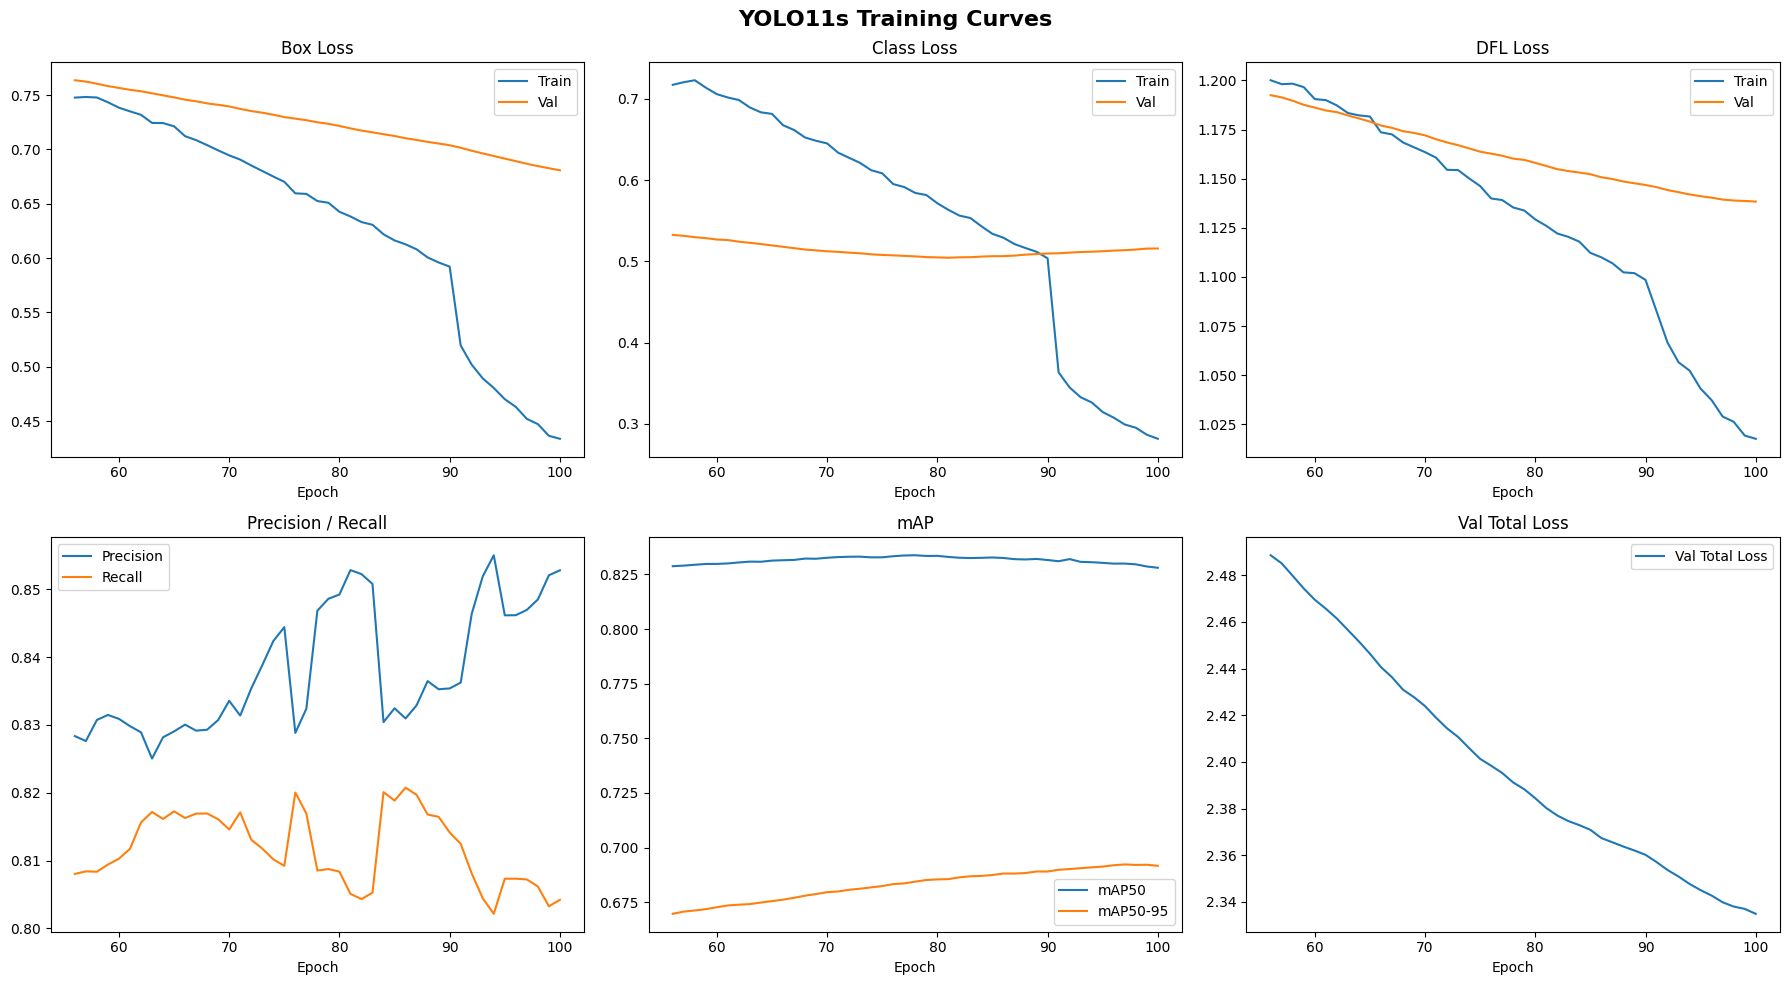

Saved plot to: /kaggle/working/training_curves_yolo11s.png


In [10]:
RESULTS_CSV = RUN_DIR / "results.csv"
if not RESULTS_CSV.exists():
    raise FileNotFoundError(f"results.csv not found at {RESULTS_CSV}")

df = pd.read_csv(RESULTS_CSV)
df.columns = [c.strip() for c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("YOLO11s Training Curves", fontsize=16, fontweight="bold")

axes[0, 0].plot(df["epoch"], df["train/box_loss"], label="Train")
axes[0, 0].plot(df["epoch"], df["val/box_loss"], label="Val")
axes[0, 0].set_title("Box Loss")
axes[0, 0].legend()

axes[0, 1].plot(df["epoch"], df["train/cls_loss"], label="Train")
axes[0, 1].plot(df["epoch"], df["val/cls_loss"], label="Val")
axes[0, 1].set_title("Class Loss")
axes[0, 1].legend()

axes[0, 2].plot(df["epoch"], df["train/dfl_loss"], label="Train")
axes[0, 2].plot(df["epoch"], df["val/dfl_loss"], label="Val")
axes[0, 2].set_title("DFL Loss")
axes[0, 2].legend()

axes[1, 0].plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
axes[1, 0].plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
axes[1, 0].set_title("Precision / Recall")
axes[1, 0].legend()

axes[1, 1].plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
axes[1, 1].plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
axes[1, 1].set_title("mAP")
axes[1, 1].legend()

val_total = df["val/box_loss"] + df["val/cls_loss"] + df["val/dfl_loss"]
axes[1, 2].plot(df["epoch"], val_total, label="Val Total Loss")
axes[1, 2].set_title("Val Total Loss")
axes[1, 2].legend()

for ax in axes.ravel():
    ax.set_xlabel("Epoch")

plt.tight_layout()
PLOT_PATH = WORK_ROOT / "training_curves_yolo11s.png"
plt.savefig(PLOT_PATH, dpi=150, bbox_inches="tight")
plt.show()

print("Saved plot to:", PLOT_PATH)

In [11]:
summary = {
    "epochs_trained": int(len(df)),
    "best_map50": float(df["metrics/mAP50(B)"].max()),
    "best_map50_epoch": int(df.loc[df["metrics/mAP50(B)"].idxmax(), "epoch"]),
    "final_map50": float(df.iloc[-1]["metrics/mAP50(B)"]),
    "final_map50_95": float(df.iloc[-1]["metrics/mAP50-95(B)"]),
    "final_precision": float(df.iloc[-1]["metrics/precision(B)"]),
    "final_recall": float(df.iloc[-1]["metrics/recall(B)"]),
}

print(summary)

{'epochs_trained': 45, 'best_map50': 0.83379, 'best_map50_epoch': 78, 'final_map50': 0.82806, 'final_map50_95': 0.69164, 'final_precision': 0.8528, 'final_recall': 0.8042}
